In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scikit_posthocs import posthoc_dunn
from scipy.stats import f_oneway, kruskal, mannwhitneyu

from statannotations.Annotator import Annotator

sns.set_context("notebook", font_scale=1.5)  # Adjust font_scale to increase font size



# Analyse CFU data from community assembly 1

## Read in data

In [2]:
repo_folder = Path("../..")

gp_folder = repo_folder / 'data/1_growth_phenotyping'
figure_folder = repo_folder / "Figures" / "2_community_assembly"

data_folder = Path("../../data/2_first_community_assembly")
file_to_open = data_folder / "cfus.csv"
df = pd.read_csv(file_to_open, index_col=0)

In [3]:
# wellmap_fn = data_folder / "wellmap.csv"
# wellmap_df = pd.read_csv(wellmap_fn, index_col=0)
# wellmap_df['Carbon source'] = wellmap_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()
# # well_to_cs = wellmap_df.set_index('Well').to_dict()['Carbon source']
# well_to_rep = wellmap_df.set_index('Well').to_dict()['Replicate']

In [4]:
palette = sns.palettes.color_palette('tab10')
palette = [palette[i] for i in [2,1,0,3]]

In [5]:
strains = ['At', 'Ct', 'Ml', 'Oa']

In [6]:
df['Carbon source'] = df['Carbon source'].str.replace('L-', '').str.replace('D-','')


In [7]:
well_to_cs = df.groupby('Well').agg({'Carbon source': 'first'}).to_dict()['Carbon source']

In [8]:
cs_class_fn = gp_folder / 'selected_carbon_sources.csv'
cs_class_df = pd.read_csv(cs_class_fn, index_col=False)
cs_class_df.rename(columns={'Metabolite name': 'Carbon source'}, inplace=True)
cs_class_df['Carbon source'] = cs_class_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()

cs_class_df.replace({'Metabolite class': {'Alcohol': 'Other', 'Nucleoside': 'Other', 'Simple sugar':'Sugar'}}, inplace=True)
cs_to_class = cs_class_df.set_index('Carbon source').to_dict()['Metabolite class']

## Define functions


In [9]:
def shannon(l):
    x_tot = np.sum(l)
    p = l/x_tot
    return -np.sum([pi*np.log(pi) for pi in p])

def simpson(l):
    x_tot = np.sum(l)
    p = l/x_tot
    return np.sum([pi*pi for pi in p])

def auxotroph_abundance(l_dict):
    x_tot =np.sum(list(l_dict.values()))
    x_aux = max(l_dict['Oa'],l_dict['Ml'])
    # print(l_dict, x_tot, x_aux)
    return x_aux/x_tot
    
def prototroph_abundance(l_dict):
    x_tot =np.sum(list(l_dict.values()))
    x_aux = max(l_dict['At'],l_dict['Ct'])
    # print(l_dict, x_tot, x_aux)
    return x_aux/x_tot


In [10]:
wells = [x for x in df.Well.unique() if x!= 'Inoculum']
strains = ['At', 'Ct', 'Ml', 'Oa']
shannon_dict = {}
simpson_dict = {}
auxotroph_dict = {}
prototroph_dict = {}
for w in wells:
    dfw = df.loc[(df.Well==w)&(df.Batch.isin([7,8]))]
    abundance = {}
    for strain in strains:
        dfws = dfw.loc[dfw.Strain == strain]
        abundance[strain] = 10**(np.log10(dfws['CFUs/mL']).mean())
    # print(w)
    shannon_dict[w] = shannon(list(abundance.values()))
    simpson_dict[w] = simpson(list(abundance.values()))
    auxotroph_dict[w] = auxotroph_abundance(abundance)
    prototroph_dict[w] = prototroph_abundance(abundance)

In [11]:
shannon_df = pd.DataFrame(index = wells)
shannon_df['Shannon index'] = shannon_df.index.map(shannon_dict)
shannon_df['Simpson index'] = shannon_df.index.map(simpson_dict)
shannon_df['Auxotroph index'] = shannon_df.index.map(auxotroph_dict)
shannon_df['Prototroph index'] = shannon_df.index.map(prototroph_dict)
shannon_df['CS'] = shannon_df.index.map(well_to_cs)
shannon_df['CS class'] = shannon_df.CS.map(cs_to_class)
shannon_df = shannon_df.loc[~shannon_df['Shannon index'].isna()].copy()
shannon_df['N CS'] = [2 if '+' in cs else 1 for cs in shannon_df['CS']]
shannon_df.loc[shannon_df['N CS']==2, 'CS class'] = 'Mix'


In [12]:
for i, row in shannon_df.iterrows():
    if isinstance(row['CS'], str):
        if  '+' in row['CS']:
            shannon_df.at[i, 'N CS'] = 2
        elif row['CS'] == 'No CS':
            shannon_df.at[i, 'N CS'] = 0    
        else:
            shannon_df.at[i, 'N CS'] = 1
    else:
        shannon_df.at[i, 'N CS'] = np.nan

In [13]:
len(shannon_df.loc[shannon_df['N CS'] == 1])    

48

In [14]:
shannon_df.to_csv(data_folder / 'shannon_index.csv')

## Group by cs class

[Text(0, 0.5, 'Shannon diversity')]

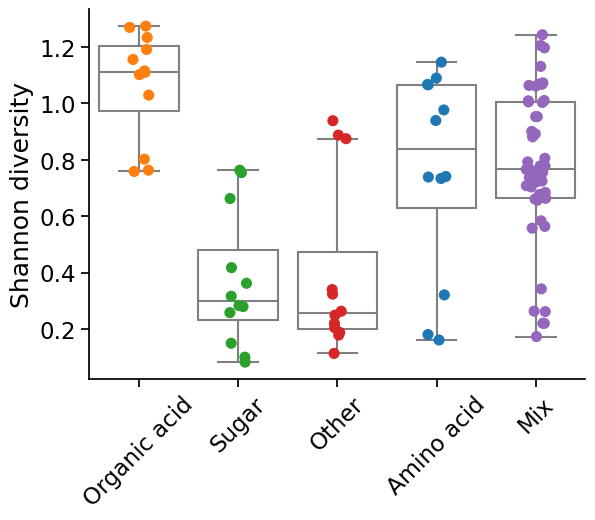

In [15]:
# idx = shannon_df['N CS'] == 1
ax = sns.boxplot(shannon_df, x = 'CS class', y = 'Shannon index',
                #  hue = 'CS class', 
                #  boxprops = {'facecolor':'none'},
                color = 'w',
                 legend=False,
                 linecolor='grey',
                    linewidth=1.5, 
                 fliersize=0)

# for patch in ax.patches:
#     r, g, b, a = patch.get_facecolor()
#     patch.set_facecolor((r, g, b, .3))

# Add in points to show each observation
sns.stripplot(shannon_df, x = 'CS class', y = 'Shannon index', 
              size=8, 
              hue = 'CS class',
              hue_order=['Amino acid', 'Organic acid', 'Sugar', 'Other', 'Mix'],
              legend = False,
            #   color = 'k'
              )#, color=".3")
# sns.move_legend(ax, loc = 1, bbox_to_anchor = (0.9,0.6,0.4,0.4))
# Rotate x labels
plt.xticks(rotation=45)
sns.despine()
ax.set(xlabel='')
ax.set(ylabel='Shannon diversity')


In [16]:
shannon_df['y'] = shannon_df['Shannon index']
shannon_df['csx'] = shannon_df['CS class']  

In [17]:

# Group the data by 'CS class' and extract the 'Shannon index' values for each group
# groups = [group['Shannon index'].values for name, group in shannon_df.loc[shannon_df['N CS']==1].groupby('CS class')]
groups = [group['Shannon index'].values for name, group in shannon_df.groupby('CS class')]

# Perform one-way ANOVA
f_stat, p_value = kruskal(*groups)

# Print the results
print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

F-statistic: 34.03580416380697
P-value: 7.32695045229498e-07


In [18]:
shannon_df['CS class'] = shannon_df['CS class'].astype(str)

In [19]:

# posthoc dunn test, with correction for multiple testing
dunn_df = posthoc_dunn(
    shannon_df, val_col="y", group_col="csx", p_adjust="fdr_bh"
)
dunn_df
remove = np.tril(np.ones(dunn_df.shape), k=0).astype("bool")
dunn_df[remove] = np.nan

molten_df = dunn_df.melt(ignore_index=False).reset_index().dropna()
molten_df

,index,variable,value
5,Amino acid,Mix,0.984836
10,Amino acid,Organic acid,0.023819
11,Mix,Organic acid,0.006640
15,Amino acid,Other,0.023819
16,Mix,Other,0.006640
17,Organic acid,Other,0.000013
20,Amino acid,Sugar,0.014154
21,Mix,Sugar,0.003363
22,Organic acid,Sugar,0.000006
23,Other,Sugar,0.866238


Organic acid vs. Sugar: Custom statistical test, P_val:6.482e-06
Organic acid vs. Other: Custom statistical test, P_val:1.324e-05


/Users/snorre/miniconda3/lib/python3.12/site-packages/statannotations/Annotator.py:786: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_63325/735868272.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='center')


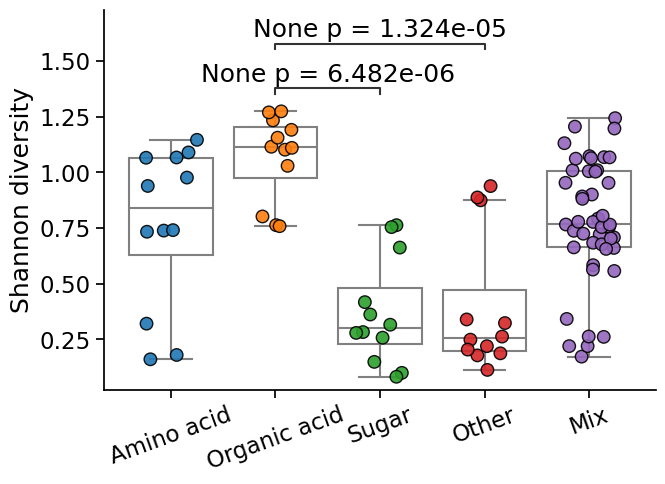

In [38]:
from statannotations.Annotator import Annotator
# cs_classes = shannon_df.loc[idx, 'CS class'].unique()
cs_classes = ['Amino acid', 'Organic acid', 'Sugar', 'Other', 'Mix']

# idx = shannon_df['N CS'] == 1
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(shannon_df, x = 'CS class', y = 'Shannon index',
                #  hue = 'CS class', 
                #  boxprops = {'facecolor':'none'},
                color = 'w',
                 legend=False,
                 linecolor='grey',
                    linewidth=1.5,
                 fliersize=0,
                 order = cs_classes,
                 ax = ax)

# for patch in ax.patches:
#     r, g, b, a = patch.get_facecolor()
#     patch.set_facecolor((r, g, b, .3))

# Add in points to show each observation
sns.stripplot(shannon_df, x = 'CS class', y = 'Shannon index', 
              size=9, 
              hue = 'CS class',
                              jitter = 0.25, 

              hue_order=cs_classes,
              edgecolor = 'k',
              alpha = 0.9,
              linewidth=1,
            #   color = 'k'
              )


pairs = [(i[1]["index"], i[1]["variable"]) for i in molten_df.iterrows()]
p_values = [i[1]["value"] for i in molten_df.iterrows()]

annotator = Annotator(
    ax, pairs, data=shannon_df, x="csx", y="y", order=cs_classes, #orient="h" 
)
# plt.ylim(0,2)
annotator.configure(text_format="full", loc="inside",
    hide_non_significant=True, alpha=0.001)
annotator.set_pvalues_and_annotate(p_values)
sns.despine()
plt.tight_layout()
ax.set_ylabel('Shannon diversity')
ax.set_xlabel('')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='center')

plt.savefig(figure_folder / "assembly_1_cs_class_boxplot_kruskal-wallis-posthoc.pdf", bbox_inches='tight')

In [21]:
annotator.configure()

## Group by N CS

In [22]:

# Group the data by 'CS class' and extract the 'Shannon index' values for each group
idx2 = shannon_df['N CS'].isin([1,2])
groups = [group['Shannon index'].values for name, group in shannon_df.loc[idx2].groupby('N CS')]

# Perform one-way ANOVA
f_stat, p_value2 = kruskal(*groups)

# Print the results
print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value2}")


# MAnn whitney
f_stat, p_val_mwu = mannwhitneyu(*groups)
print('Mann Whitney U', mannwhitneyu(*groups))
print([len(g) for g in groups])

F-statistic: 1.6090425531915002
P-value: 0.20462644184355774
Mann Whitney U MannwhitneyuResult(statistic=np.float64(915.0), pvalue=np.float64(0.20600165139546445))
[48, 45]


In [23]:
ncs_name = {1: 'One', 2: 'Two'}
shannon_df['# Carbon sources'] = shannon_df['N CS'].map(ncs_name)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

One vs. Two: Custom statistical test, P_val:2.060e-01


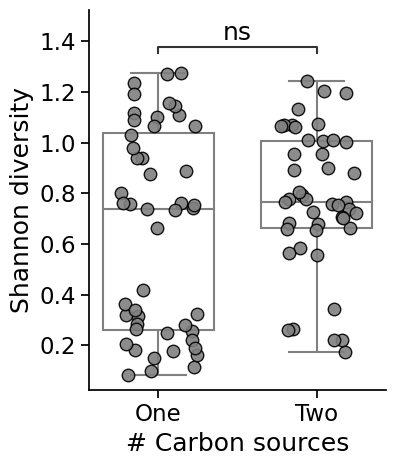

In [37]:
fig, ax = plt.subplots(figsize=(4,5))
sns.boxplot(shannon_df.loc[idx2], x = '# Carbon sources', y = 'Shannon index',
                #  hue = 'CS class', 
                #  boxprops = {'facecolor':'none'},
                color = 'w',
                 legend=False,
                 linecolor='grey',
                 linewidth=1.5, 
                 width = 0.7,
                 fliersize=0,
                 ax=ax)

# for patch in ax.patches:
#     r, g, b, a = patch.get_facecolor()
#     patch.set_facecolor((r, g, b, .3))

# Add in points to show each observation
sns.stripplot(shannon_df.loc[idx2], x = '# Carbon sources', y = 'Shannon index', 
              size=9,
              jitter = 0.25,
              edgecolor = 'k',
              alpha = 0.9,
              linewidth=1, 
              # hue = '# Carbon sources'
              color = 'grey'
              )#, color=".3")
# sns.move_legend(ax, loc = 1, bbox_to_anchor = (0.9,0.6,0.4,0.4))
sns.despine()
ax.set(ylabel='')


pairs = [['One','Two']]
# # pairs = [(i[1]["index"], i[1]["variable"]) for i in molten_df.iterrows()]
p_values = [p_val_mwu]

annotator = Annotator(
    ax, pairs, data=shannon_df.loc[idx2], x='# Carbon sources', y="y", order=['One', 'Two'], #orient="h" 
)
annotator.configure(text_format="star", loc="inside",
    # hide_non_significant=True
    )
annotator.set_pvalues_and_annotate(p_values)


# for i, (lbl,g) in enumerate(shannon_df.loc[idx2].groupby('# Carbon sources')):
#     if lbl == 'One':
#         x = 0
#     else:
#         x = 1
#     ax.text(
#         i,
#         1.85,
#         f'N={len(g)}',
#         ha='center',
#         va='bottom',
#         fontsize=12
#     )

plt.tight_layout()
ax.set_ylabel('Shannon diversity')
plt.savefig(figure_folder / "assembly_1_n_cs_boxplot_kruskal-wallis-posthoc.pdf",  bbox_inches='tight')
plt.savefig(figure_folder / "assembly_1_n_cs_boxplot_kruskal-wallis-posthoc.png", dpi=300, bbox_inches='tight')

## Group by auxotrophy

In [25]:
abundance_threshold = 0.1
shannon_df['Abundant auxotroph'] = shannon_df['Auxotroph index'] > abundance_threshold
shannon_df['Abundant prototroph'] = shannon_df['Prototroph index'] > abundance_threshold


In [26]:

groups = [group['Shannon index'].values for name, group in shannon_df.loc[idx2].groupby(['Abundant auxotroph'])]

# Perform one-way ANOVA
f_stat, p_value3 = kruskal(*groups)
print(f_stat, p_value)

fstat_wu2, p_val_mwu_2 = mannwhitneyu(*groups)
print(mannwhitneyu(*groups))

36.86028105632971 7.32695045229498e-07
MannwhitneyuResult(statistic=np.float64(289.0), pvalue=np.float64(1.2998181369631118e-09))


In [27]:
shannon_df

,Shannon index,Simpson index,Auxotroph index,Prototroph index,CS,CS class,N CS,y,csx,# Carbon sources,Abundant auxotroph,Abundant prototroph
A1,1.102104,0.384901,0.540792,0.226230,Acetate,Organic acid,1,1.102104,Organic acid,One,True,True
A2,1.233758,0.308168,0.290068,0.370636,Acetate,Organic acid,1,1.233758,Organic acid,One,True,True
A3,1.191287,0.331467,0.445219,0.257047,Acetate,Organic acid,1,1.191287,Organic acid,One,True,True
A4,0.257947,0.891567,0.041115,0.943236,Glucose,Sugar,1,0.257947,Sugar,One,False,True
A5,0.316198,0.856899,0.061345,0.923575,Glucose,Sugar,1,0.316198,Sugar,One,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
H5,0.583520,0.683301,0.149034,0.812199,Malate + Isoleucine,Mix,2,0.583520,Mix,Two,True,True
H6,0.563743,0.681375,0.170155,0.807447,Malate + Isoleucine,Mix,2,0.563743,Mix,Two,True,True
H7,0.342086,0.850254,0.018514,0.920258,Mannitol + Myo-inositol,Mix,2,0.342086,Mix,Two,False,True
H8,0.263218,0.892160,0.014283,0.943682,Mannitol + Myo-inositol,Mix,2,0.263218,Mix,Two,False,True


False vs. True: Custom statistical test, P_val:1.300e-09


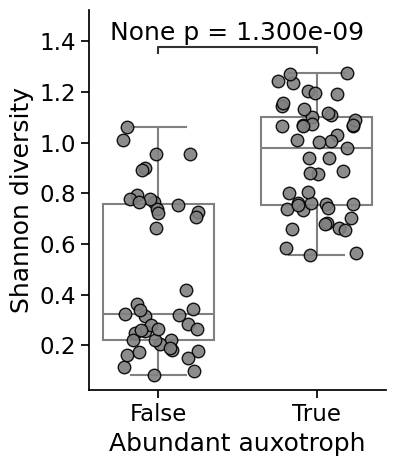

In [40]:
fig, ax = plt.subplots(figsize=(4,5))
sns.boxplot(shannon_df.loc[idx2], x = 'Abundant auxotroph', y = 'Shannon index',
                #  hue = 'CS class', 
                #  boxprops = {'facecolor':'none'},
                color = 'w',
                 legend=False,
                 linecolor='grey',
                 linewidth=1.5, 
                 width=0.7,
                 fliersize=0,
                 ax=ax)

# for patch in ax.patches:
#     r, g, b, a = patch.get_facecolor()
#     patch.set_facecolor((r, g, b, .3))

# Add in points to show each observation
sns.stripplot(shannon_df.loc[idx2], x = 'Abundant auxotroph', y = 'Shannon index', 
              size=9,
              jitter = 0.25, 
            #   width = 0.6,
              # hue = '# Carbon sources'
              color = 'grey',
              edgecolor = 'k',
              linewidth=1,
              alpha = 0.9
              )#, color=".3")
# sns.move_legend(ax, loc = 1, bbox_to_anchor = (0.9,0.6,0.4,0.4))
sns.despine()
ax.set(ylabel='')

# for i, (lbl,g) in enumerate(shannon_df.loc[idx2].groupby('Abundant auxotroph')):
#     if lbl == False:
#         x = 0
#     else:
#         x = 1
#     ax.text(
#         i,
#         1.85,
#         f'N={len(g)}',
#         ha='center',
#         va='bottom',
#         fontsize=12
#     )


# pairs = [['One','Two']]
pairs = [[False,True]]
# # pairs = [(i[1]["index"], i[1]["variable"]) for i in molten_df.iterrows()]
p_values = [p_val_mwu_2]

annotator = Annotator(
    ax, pairs, data=shannon_df.loc[idx2], x='Abundant auxotroph', y="y", order=[False, True], #orient="h" 
)
annotator.configure(text_format="full", loc="inside",
    # hide_non_significant=True
    )
annotator.set_pvalues_and_annotate(p_values)

plt.tight_layout()
ax.set_ylabel('Shannon diversity')
plt.savefig(figure_folder / "assembly_1_auxotroph_boxplot_kruskal-wallis-posthoc.pdf",  bbox_inches='tight')
# plt.savefig(figure_folder / "assembly_1_n_cs_boxplot_kruskal-wallis-posthoc.png", dpi=300, bbox_inches='tight')

In [41]:

groups = [group['Shannon index'].values for name, group in shannon_df.loc[idx2].groupby(['Abundant auxotroph', '# Carbon sources'])]

# Perform one-way ANOVA
f_stat, p_value3 = kruskal(*groups)
print(f_stat, p_value)

50.9758453675675 7.32695045229498e-07


In [42]:
shannon_df['xxx'] = shannon_df['Abundant auxotroph'].astype(str)+ '/'+shannon_df['# Carbon sources']

In [43]:

# posthoc dunn test, with correction for multiple testing
dunn_df = posthoc_dunn(
    shannon_df.loc[idx2], val_col="y", group_col="xxx", p_adjust="fdr_bh"
)
dunn_df
remove = np.tril(np.ones(dunn_df.shape), k=0).astype("bool")
dunn_df[remove] = np.nan

molten_df2 = dunn_df.melt(ignore_index=False).reset_index().dropna()
molten_df2

,index,variable,value
4,False/One,False/Two,6.228981e-04
8,False/One,True/One,8.454469e-11
9,False/Two,True/One,2.968867e-03
12,False/One,True/Two,1.511558e-07
13,False/Two,True/Two,6.489843e-02
14,True/One,True/Two,2.909301e-01


Two_False vs. Two_True: Custom statistical test, P_val:6.490e-02
One_False vs. One_True: Custom statistical test, P_val:8.454e-11
One_False vs. Two_False: Custom statistical test, P_val:6.229e-04


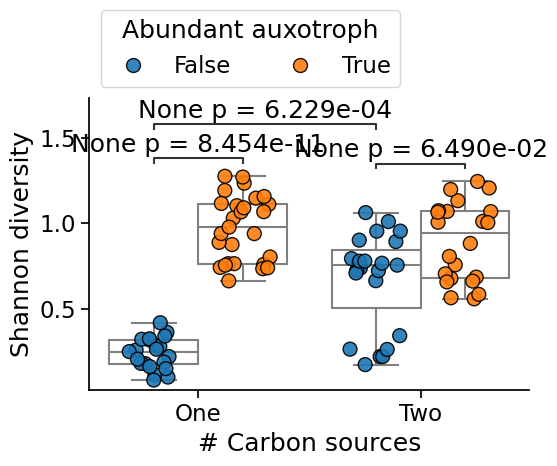

In [47]:

fig, ax = plt.subplots(figsize=(6,5))

sns.boxplot(shannon_df.loc[idx2], hue = 'Abundant auxotroph', y = 'Shannon index', x ='# Carbon sources', palette='tab10', legend=None, 
            color = 'w',
            dodge=True,
                 linecolor='grey',
                    linewidth=1.5, 
                 boxprops = {'facecolor':'none'},
                 ax=ax,
                 fliersize=0)#,)

# for patch in ax.patches:
#     r, g, b, a = patch.get_facecolor()
#     patch.set_facecolor((r, g, b, .3))

# Add in points to show each observation
ax = sns.stripplot(shannon_df.loc[idx2], hue = 'Abundant auxotroph', y = 'Shannon index', x = '# Carbon sources', size=10, jitter = 0.25, palette='tab10', dodge=0.5, legend=True,
                    linewidth = 1, edgecolor = 'k', alpha = 0.9)#, color=".3")
# sns.move_legend(ax, loc = 1, bbox_to_anchor = (0.9,0.9,0.4,0.4), ncol=2)
sns.despine()

pairs = [(('One', False),('Two', False)),
         (('One', False),('One', True)),
         (('Two', False),('Two', True)),
         # (('One', True),('Two', False))
         ]
# # pairs = [(i[1]["index"], i[1]["variable"]) for i in molten_df.iterrows()]
p_values3 = list(molten_df2['value'].values[:2])+[molten_df2['value'].values[4]]

annotator = Annotator(
    ax, pairs, data=shannon_df.loc[idx2], x='# Carbon sources', y="y", 
    hue = 'Abundant auxotroph',
    order=['One', 'Two'], #orient="h" 
)
annotator.configure(text_format="full", loc="inside",
    # hide_non_significant=True
    )
annotator.set_pvalues_and_annotate(p_values3)
sns.move_legend(ax, loc = 3, bbox_to_anchor = (0,1), ncol=2)

plt.tight_layout()
ax.set_ylabel('Shannon diversity')
plt.savefig(figure_folder / "assembly_1_n_cs_and_abundant_auxotroph_boxplot_kruskal-wallis-posthoc.pdf")
plt.savefig(figure_folder / "assembly_1_n_cs_and_abundant_auxotroph_boxplot_kruskal-wallis-posthoc.png", dpi=300, bbox_inches='tight')

# Abundant species

In [33]:
pca_df = pd.read_csv(data_folder / 'pca.csv', index_col=0)
well_to_at_rank = pca_df.to_dict()['At rank']

In [34]:
shannon_df['At rank'] = shannon_df.index.map(well_to_at_rank)
shannon_df['At rank 1'] = shannon_df['At rank'] == 1

In [49]:
# fig, ax = plt.subplots(figsize=(7,5))
# sns.boxplot(shannon_df.loc[idx2], x = 'At rank 1', y = 'Shannon index',
#                 # hue = 'Abundant auxotroph',
#                 color = 'w',
#             dodge=True,
#             legend=None,
#                  linecolor='grey',
#                     linewidth=1.5, 
#                   boxprops = {'facecolor':'none'},
                  
#                  fliersize=0,
#                  ax=ax)

# # for patch in ax.patches:
# #     r, g, b, a = patch.get_facecolor()
# #     patch.set_facecolor((r, g, b, .3))

# # Add in points to show each observation
# sns.stripplot(shannon_df.loc[idx2], x = 'At rank 1', y = 'Shannon index', 
#               size=7, 
#               # hue = 'Abundant auxotroph',
#               palette='tab10',
#               dodge=0.5,
#             #   color = 'grey'
#               )#, color=".3")
# # sns.move_legend(ax, loc = 1, bbox_to_anchor = (0.9,0.6,0.4,0.4))
# sns.despine()
# ax.set(ylabel='')


# pairs = [['One','Two']]
# # # pairs = [(i[1]["index"], i[1]["variable"]) for i in molten_df.iterrows()]
# p_values = [p_value2]

# # annotator = Annotator(
# #     ax, pairs, data=shannon_df.loc[idx2], x='# Carbon sources', y="y", order=['One', 'Two'], #orient="h" 
# # )
# # annotator.configure(text_format="star", loc="inside",
# #     # hide_non_significant=True
# #     )
# # annotator.set_pvalues_and_annotate(p_values)

# plt.tight_layout()
# ax.set_ylabel('Shannon diversity')
# # plt.savefig("../../Figures/assembly_1_n_cs_boxplot_kruskal-wallis-posthoc.pdf")